# Load Data

In [ ]:
import urllib.request

In [ ]:
import glob
import pickle
import pandas as pd

dfs = []

for path in glob.glob('*_full_hF1.pkl'):
    dataset_name = path.replace('_full_hF1.pkl', '')
    df = pd.read_pickle(path)
    df['Dataset'] = dataset_name
    dfs.append(df)

AKE_full_hF1 = pd.concat(dfs, ignore_index=True)

In [ ]:
AKE_full_hF1

,TF,TfIdf,KPMiner,YAKE,TextRank1,SingleRank,PositionRank,LMRANK,Dataset,KeyBERT,MDERANK
0,0.222222,0.444444,0.240000,0.222222,0.000000,0.000000,0.244898,0.153846,NUS,NaN,NaN
1,0.000000,0.246154,0.246154,0.246154,0.000000,0.000000,0.242424,0.200000,NUS,NaN,NaN
2,0.369231,0.459016,0.466667,0.270270,0.000000,0.000000,0.160000,0.258065,NUS,NaN,NaN
3,0.204380,0.351648,0.395062,0.275862,0.000000,0.168168,0.278146,0.354680,NUS,NaN,NaN
4,0.000000,0.000000,0.415584,0.137931,0.000000,0.000000,0.143590,0.329897,NUS,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
5842,0.000000,0.000000,0.294118,0.000000,0.228571,0.000000,0.000000,0.222222,DUC-2001,NaN,NaN
5843,0.166667,0.210526,0.193548,0.292683,0.000000,0.173913,0.170213,0.181818,DUC-2001,NaN,NaN
5844,0.194175,0.169014,0.169014,0.186047,0.000000,0.333333,0.181818,0.181818,DUC-2001,NaN,NaN
5845,0.172414,0.163265,0.179104,0.163265,0.000000,0.181818,0.000000,0.301075,DUC-2001,NaN,NaN


# Summary

In [ ]:
import numpy as np

summary = AKE_full_hF1.groupby('Dataset').agg(['mean', 'std'])

summary_table = summary.stack(level=1, future_stack=True).reset_index()

summary_table.rename(columns={'level_1': 'Stat'}, inplace=True)

dataset_order = ['SemEval-2010', 'NUS', 'Inspec', 'KDD', 'WWW', 'SemEval-2017', 'DUC-2001', '500N-KP-Crowd']

summary_table['Dataset'] = pd.Categorical(summary_table['Dataset'], categories=dataset_order, ordered=True)
summary_table['Stat'] = pd.Categorical(summary_table['Stat'], categories=['mean', 'std'], ordered=True)
summary_table = summary_table.sort_values(['Dataset', 'Stat']).reset_index(drop=True)

summary_table_rounded = summary_table.round(3)

In [ ]:
summary_table_rounded

,Dataset,Stat,TF,TfIdf,KPMiner,YAKE,TextRank1,SingleRank,PositionRank,LMRANK,KeyBERT,MDERANK
0,SemEval-2010,mean,0.134,0.207,0.287,0.190,0.035,0.053,0.112,0.164,NaN,NaN
1,SemEval-2010,std,0.109,0.115,0.119,0.119,0.059,0.073,0.092,0.099,NaN,NaN
2,NUS,mean,0.144,0.258,0.341,0.233,0.021,0.039,0.113,0.145,NaN,NaN
3,NUS,std,0.144,0.167,0.171,0.150,0.054,0.074,0.118,0.136,NaN,NaN
4,Inspec,mean,0.125,0.234,0.092,0.260,0.149,0.287,0.287,0.364,NaN,NaN
5,Inspec,std,0.133,0.163,0.133,0.162,0.157,0.188,0.180,0.200,NaN,NaN
6,KDD,mean,0.092,0.175,0.174,0.119,0.084,0.089,0.148,0.164,0.146,0.138
7,KDD,std,0.159,0.200,0.211,0.179,0.155,0.154,0.187,0.199,0.191,0.189
8,WWW,mean,0.123,0.186,0.175,0.118,0.084,0.074,0.122,0.142,NaN,NaN
9,WWW,std,0.165,0.192,0.200,0.160,0.153,0.149,0.182,0.182,NaN,NaN


# Normality Test

In [ ]:
from scipy import stats

norm_results = []

AKE_methods = [col for col in AKE_full_hF1.columns if col != 'Dataset']

for ds_name, group in AKE_full_hF1.groupby('Dataset'):
    active_methods = [m for m in AKE_methods if not group[m].isnull().all()]

    for method in active_methods:
        observations = group[method]

        z_scores = (observations - observations.mean()) / observations.std()
        stat, p_val = stats.kstest(z_scores, 'norm')

        norm_results.append({
            'Dataset': ds_name,
            'Method': method,
            'K-S Stat': f"{stat:.4f}",
            'p-value': f"{p_val:.4e}",
            'Is_Normal': 'Yes' if p_val > 0.05 else 'No'
        })

norm_summary = pd.DataFrame(norm_results)

In [ ]:
norm_summary

,Dataset,Method,K-S Stat,p-value,Is_Normal
0,500N-KP-Crowd,TF,0.0536,1.0896e-01,Yes
1,500N-KP-Crowd,TfIdf,0.0549,9.4094e-02,Yes
2,500N-KP-Crowd,KPMiner,0.0614,4.3931e-02,No
3,500N-KP-Crowd,YAKE,0.0376,4.6944e-01,Yes
4,500N-KP-Crowd,TextRank1,0.0501,1.5708e-01,Yes
...,...,...,...,...,...
63,WWW,YAKE,0.3689,6.7218e-163,No
64,WWW,TextRank1,0.4587,1.6994e-256,No
65,WWW,SingleRank,0.4734,3.3479e-274,No
66,WWW,PositionRank,0.3990,1.5209e-191,No


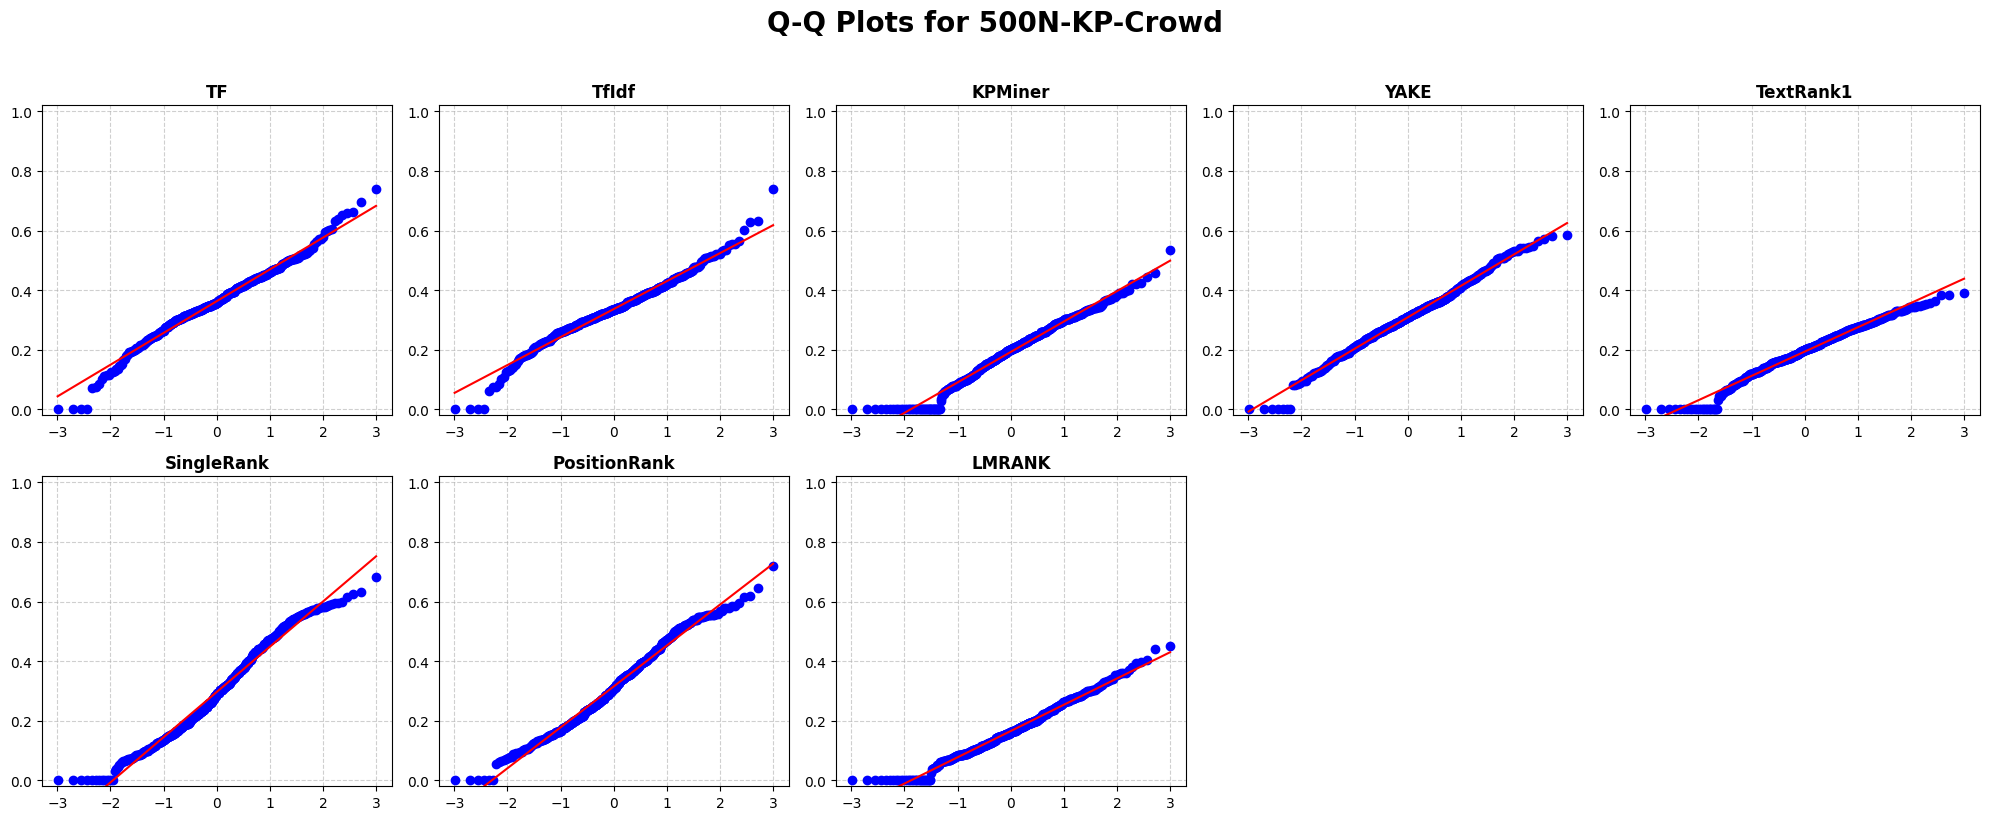

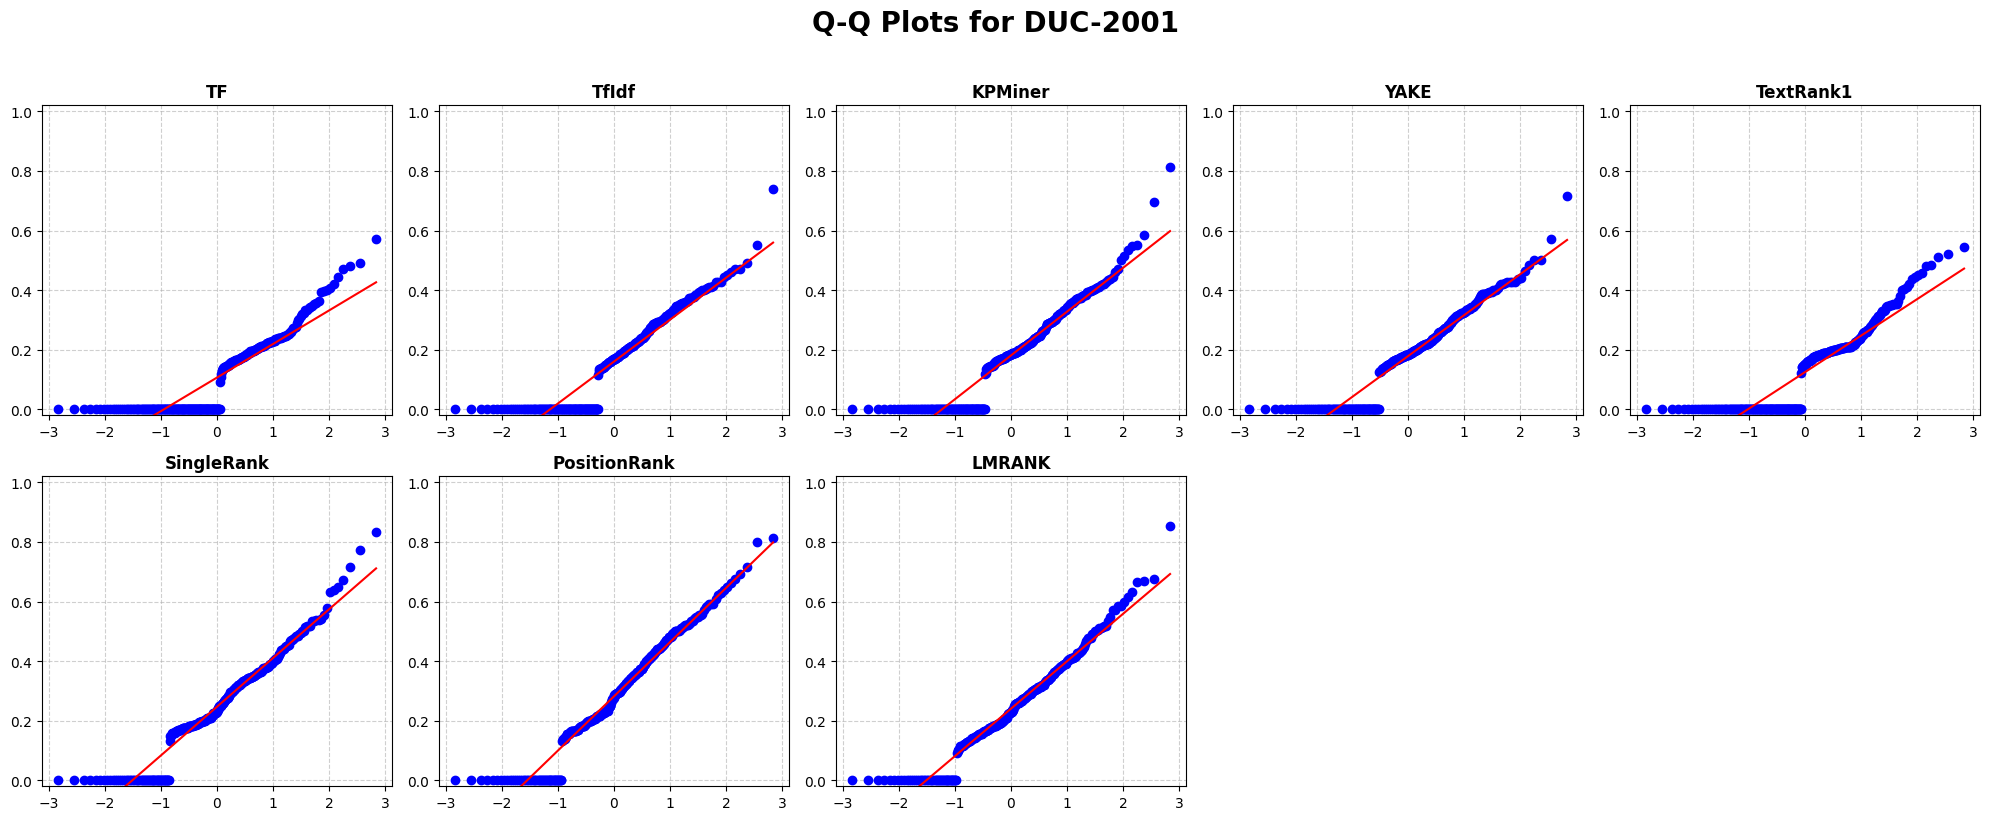

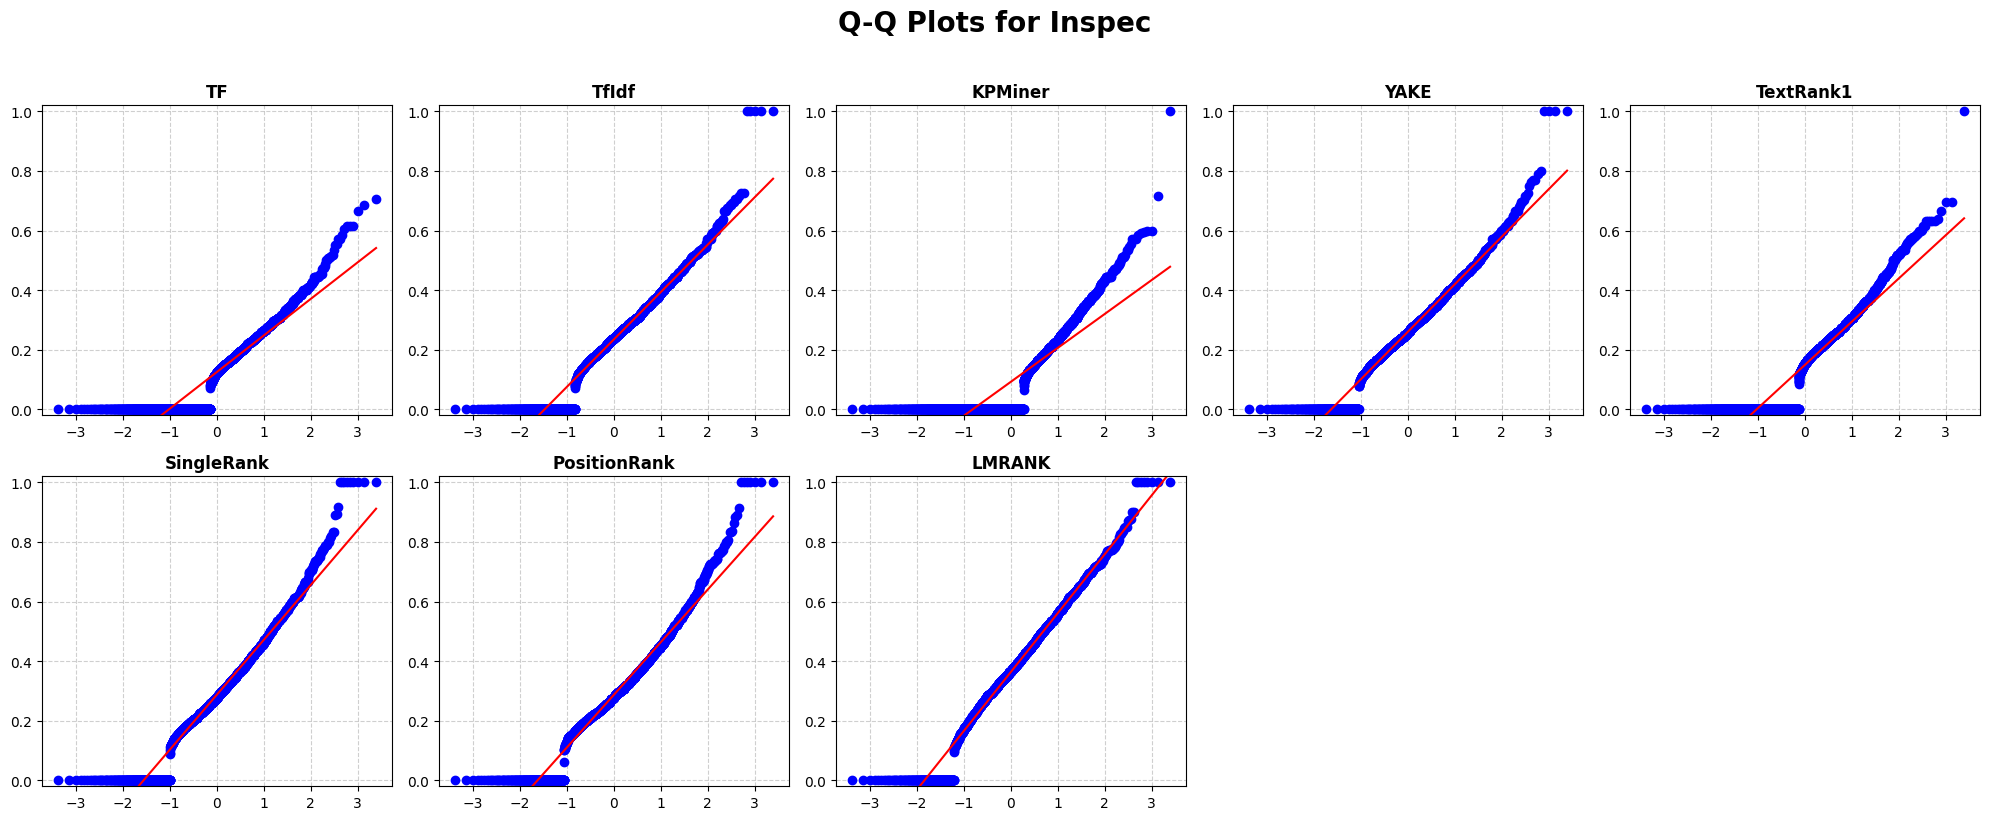

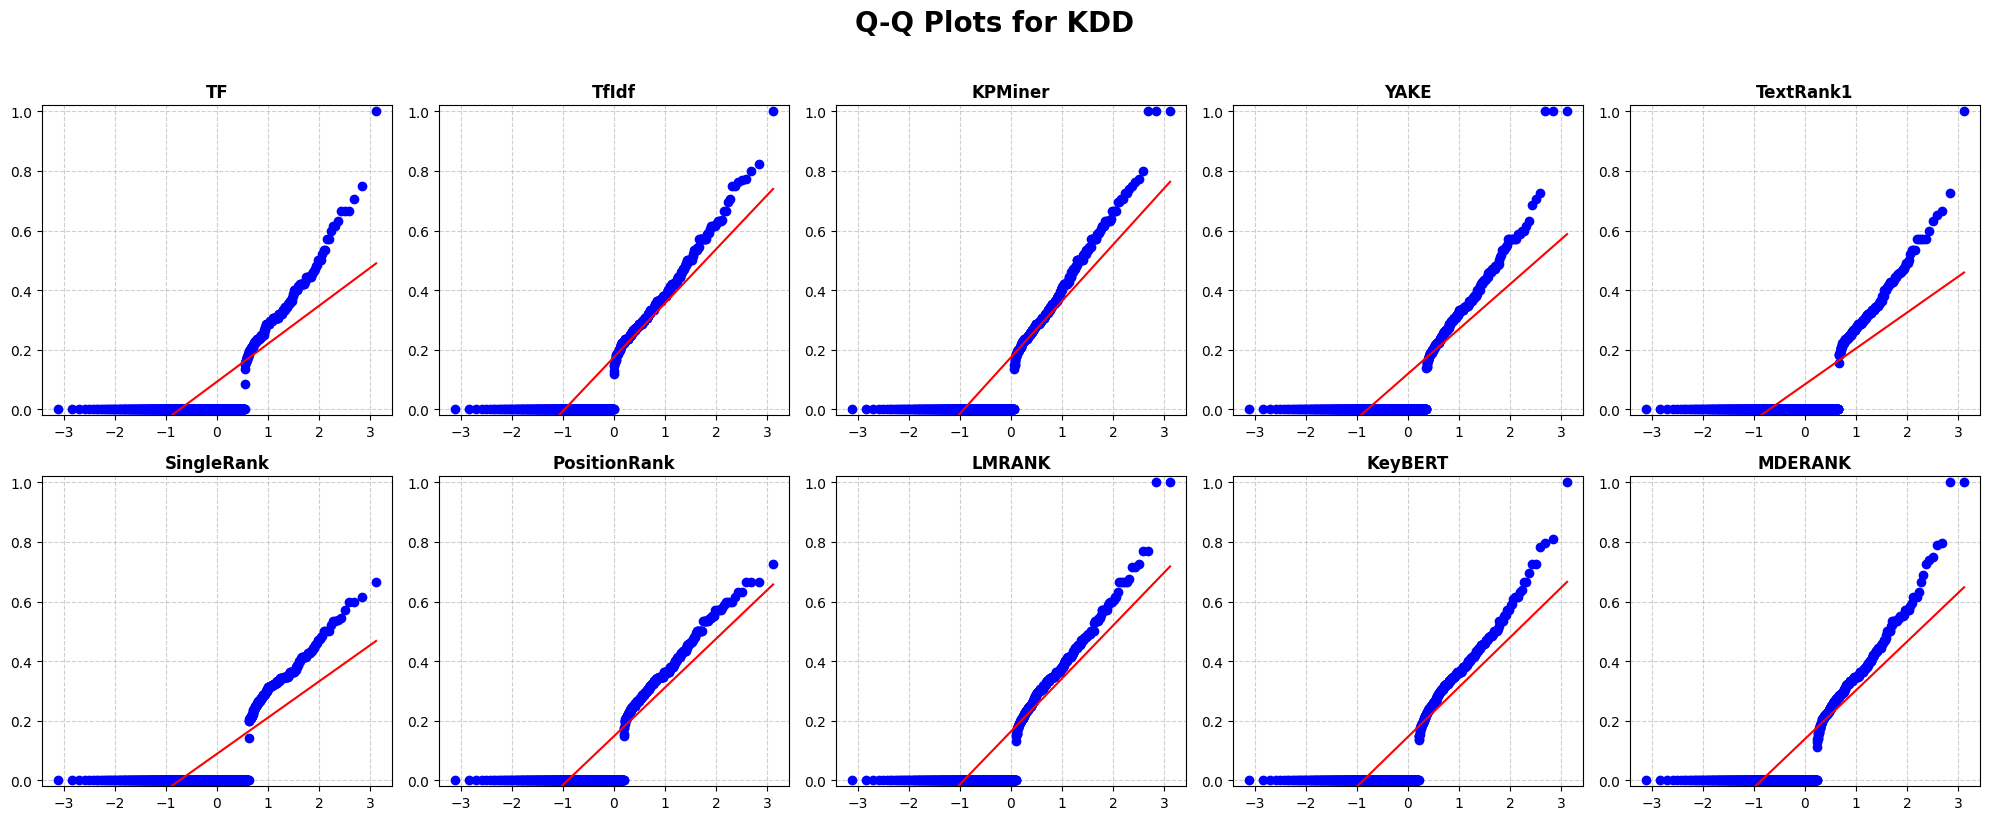

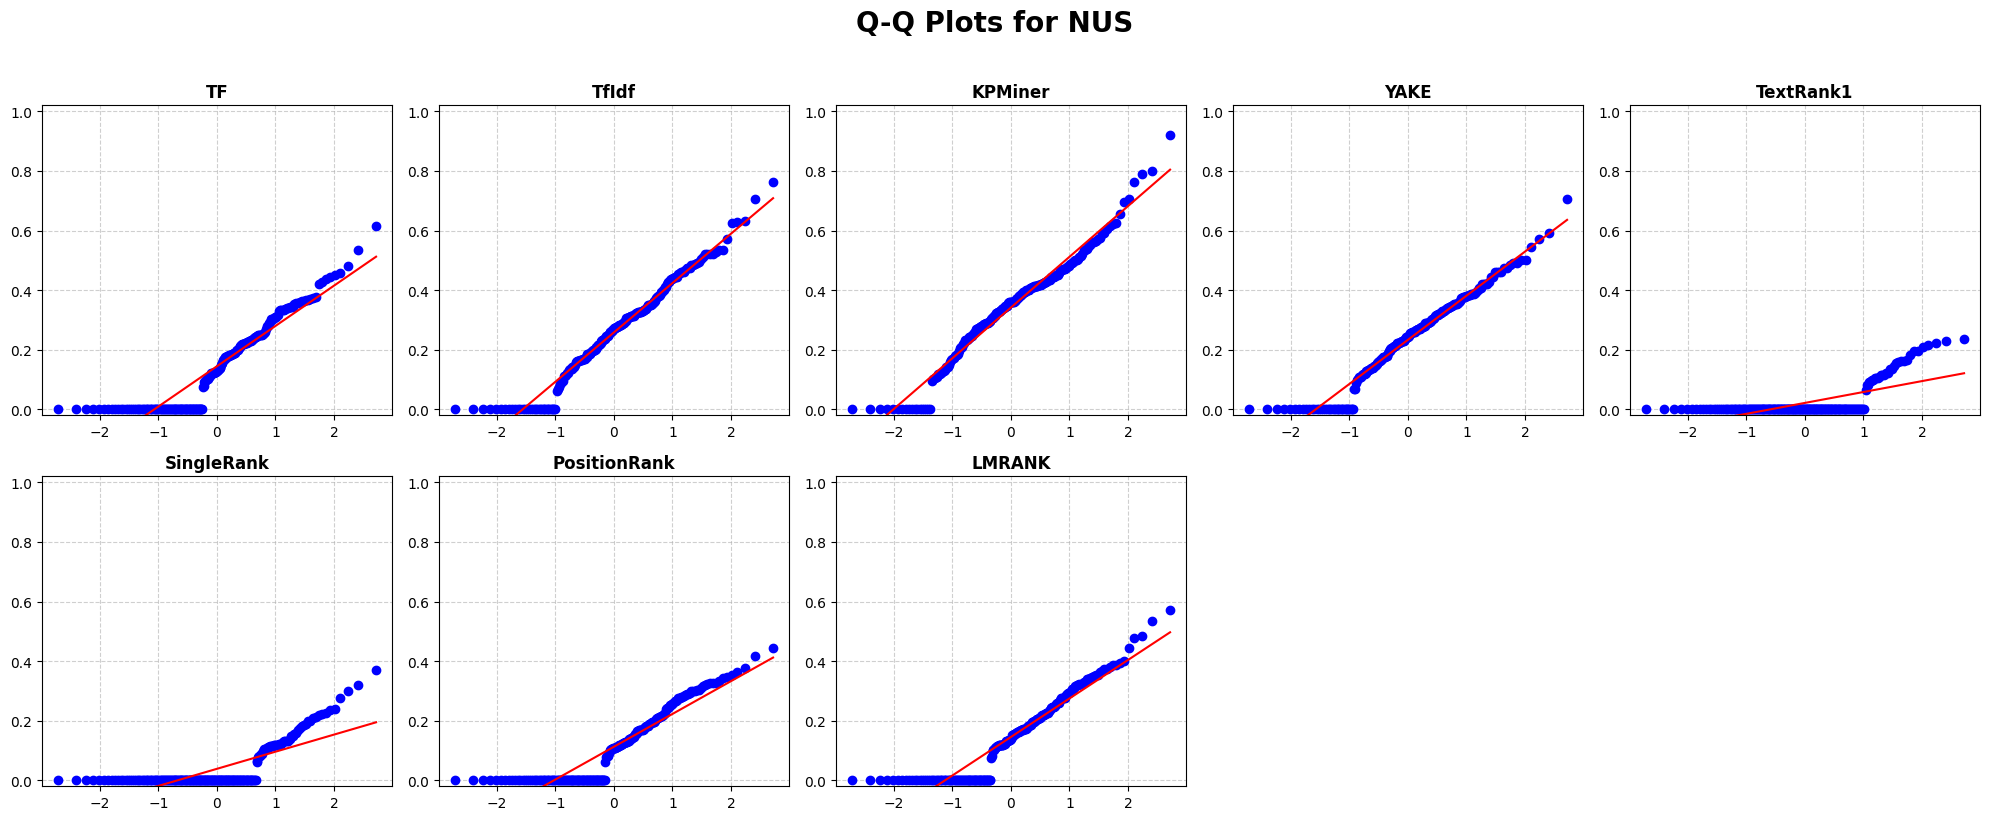

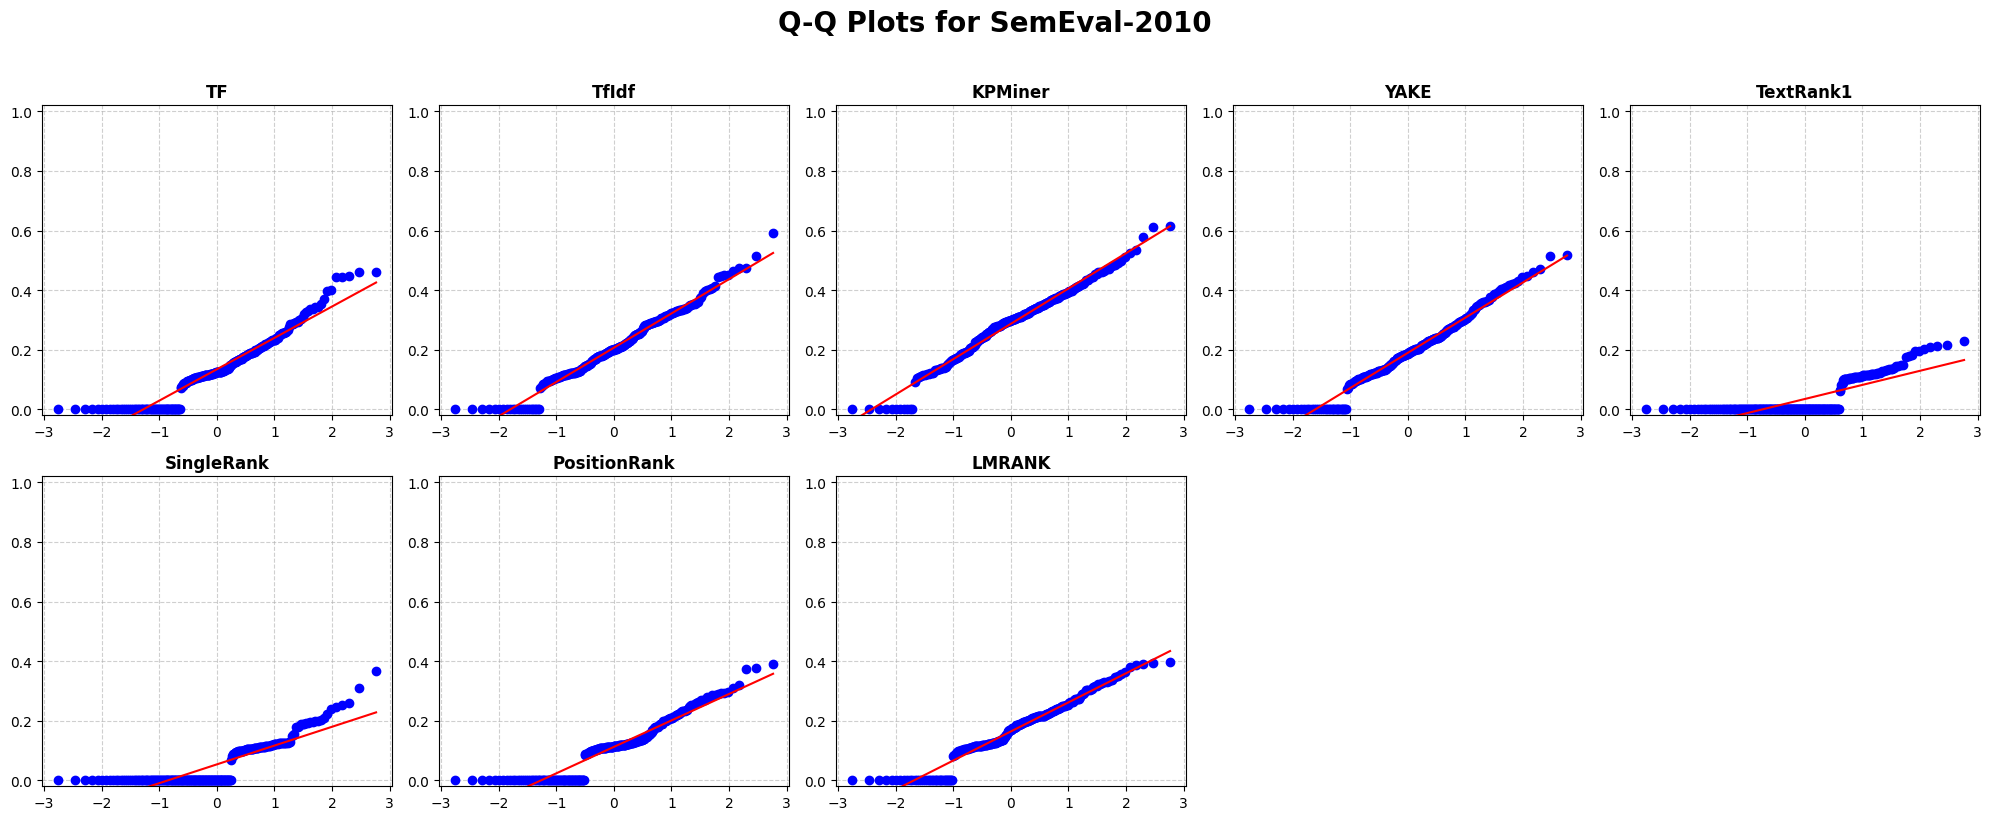

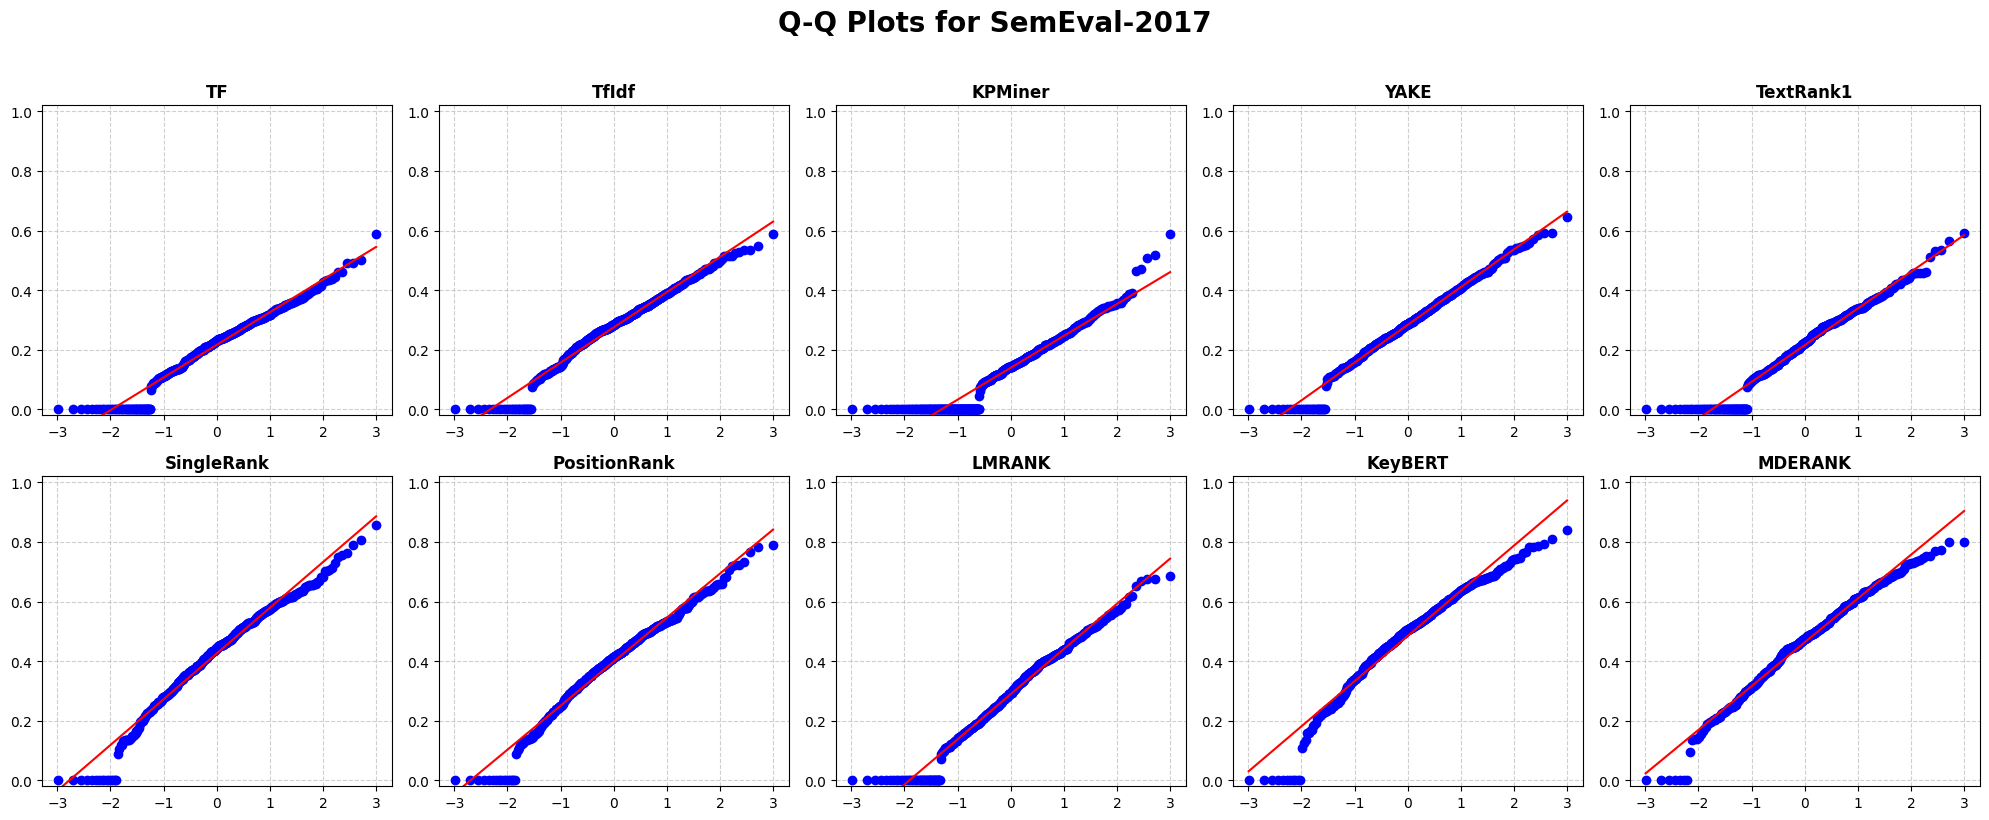

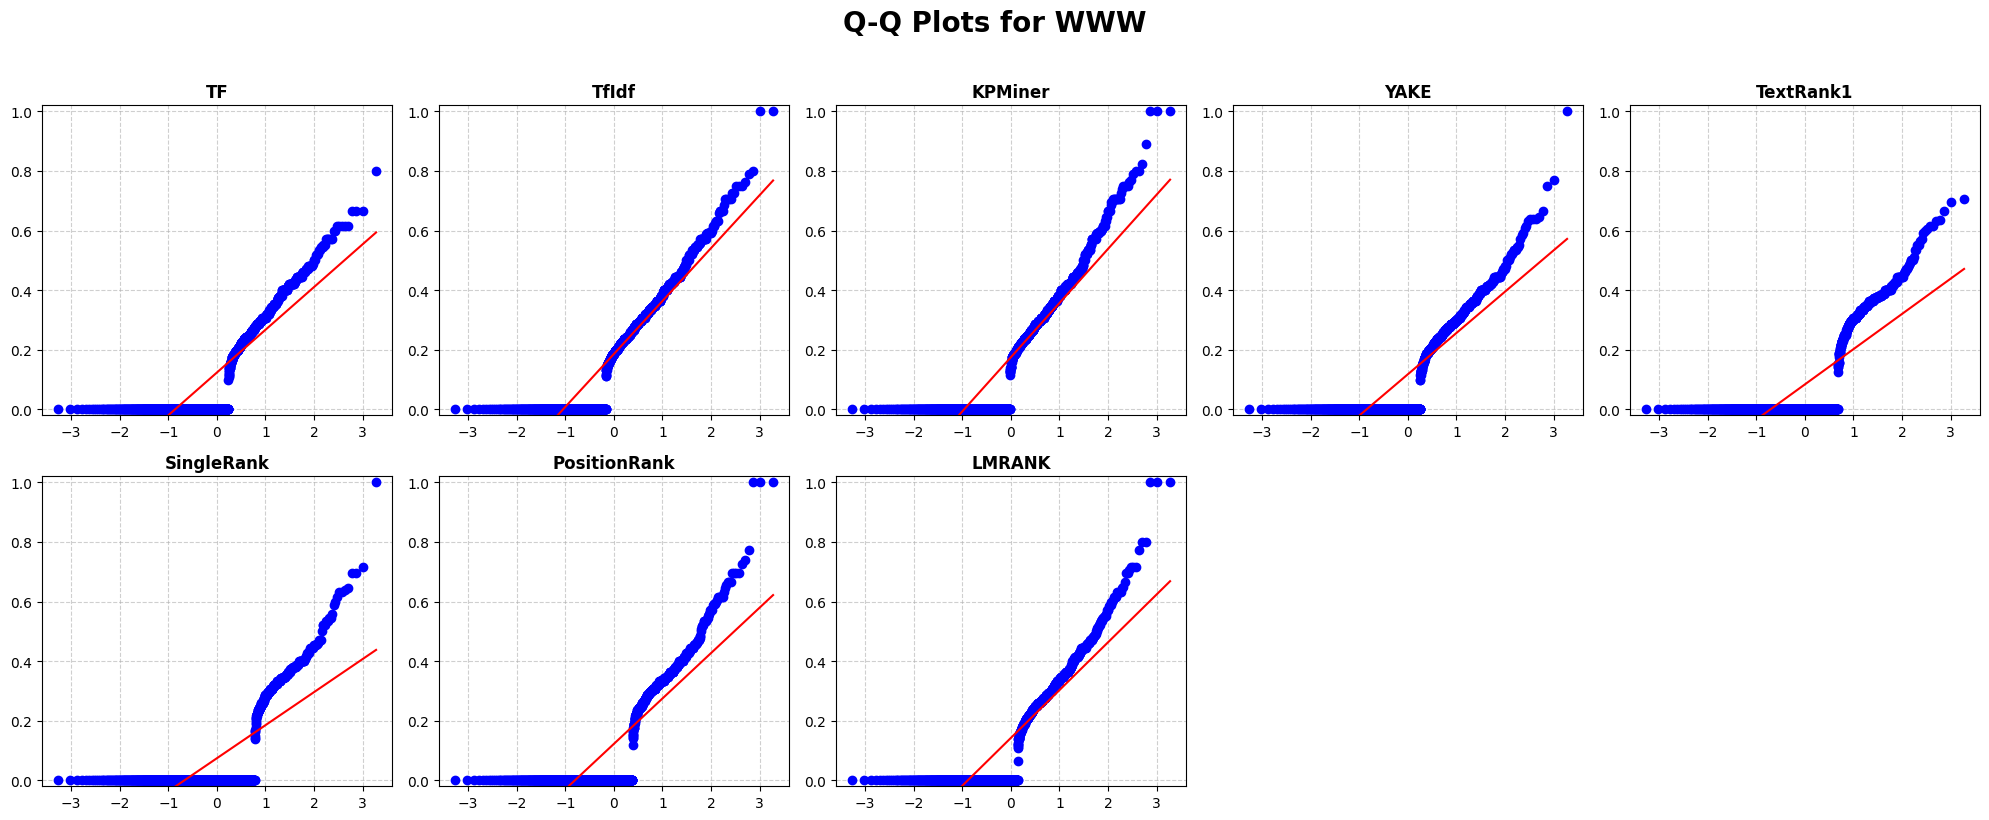

In [ ]:
import matplotlib.pyplot as plt

for ds_name, group in AKE_full_hF1.groupby('Dataset'):
    active_methods = [m for m in AKE_methods if not group[m].isnull().all()]
    num_methods = len(active_methods)

    cols = 5
    rows = 2

    fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows), squeeze=False)
    fig.suptitle(f"Q-Q Plots for {ds_name}", fontsize=20, y=1.02, fontweight='bold')

    axes_flat = axes.flatten()

    for i, method in enumerate(active_methods):
        ax = axes_flat[i]
        observations = group[method]

        stats.probplot(observations, dist="norm", plot=ax)

        ax.set_ylim(-0.02, 1.02)
        ax.grid(True, linestyle='--', alpha=0.6, zorder=0)

        ax.set_title(f"{method}", fontsize=12, fontweight='semibold')
        ax.set_xlabel("")
        ax.set_ylabel("")

    for j in range(num_methods, len(axes_flat)):
        fig.delaxes(axes_flat[j])

    plt.tight_layout()
    plt.show()
    print("\n" + "="*100 + "\n")

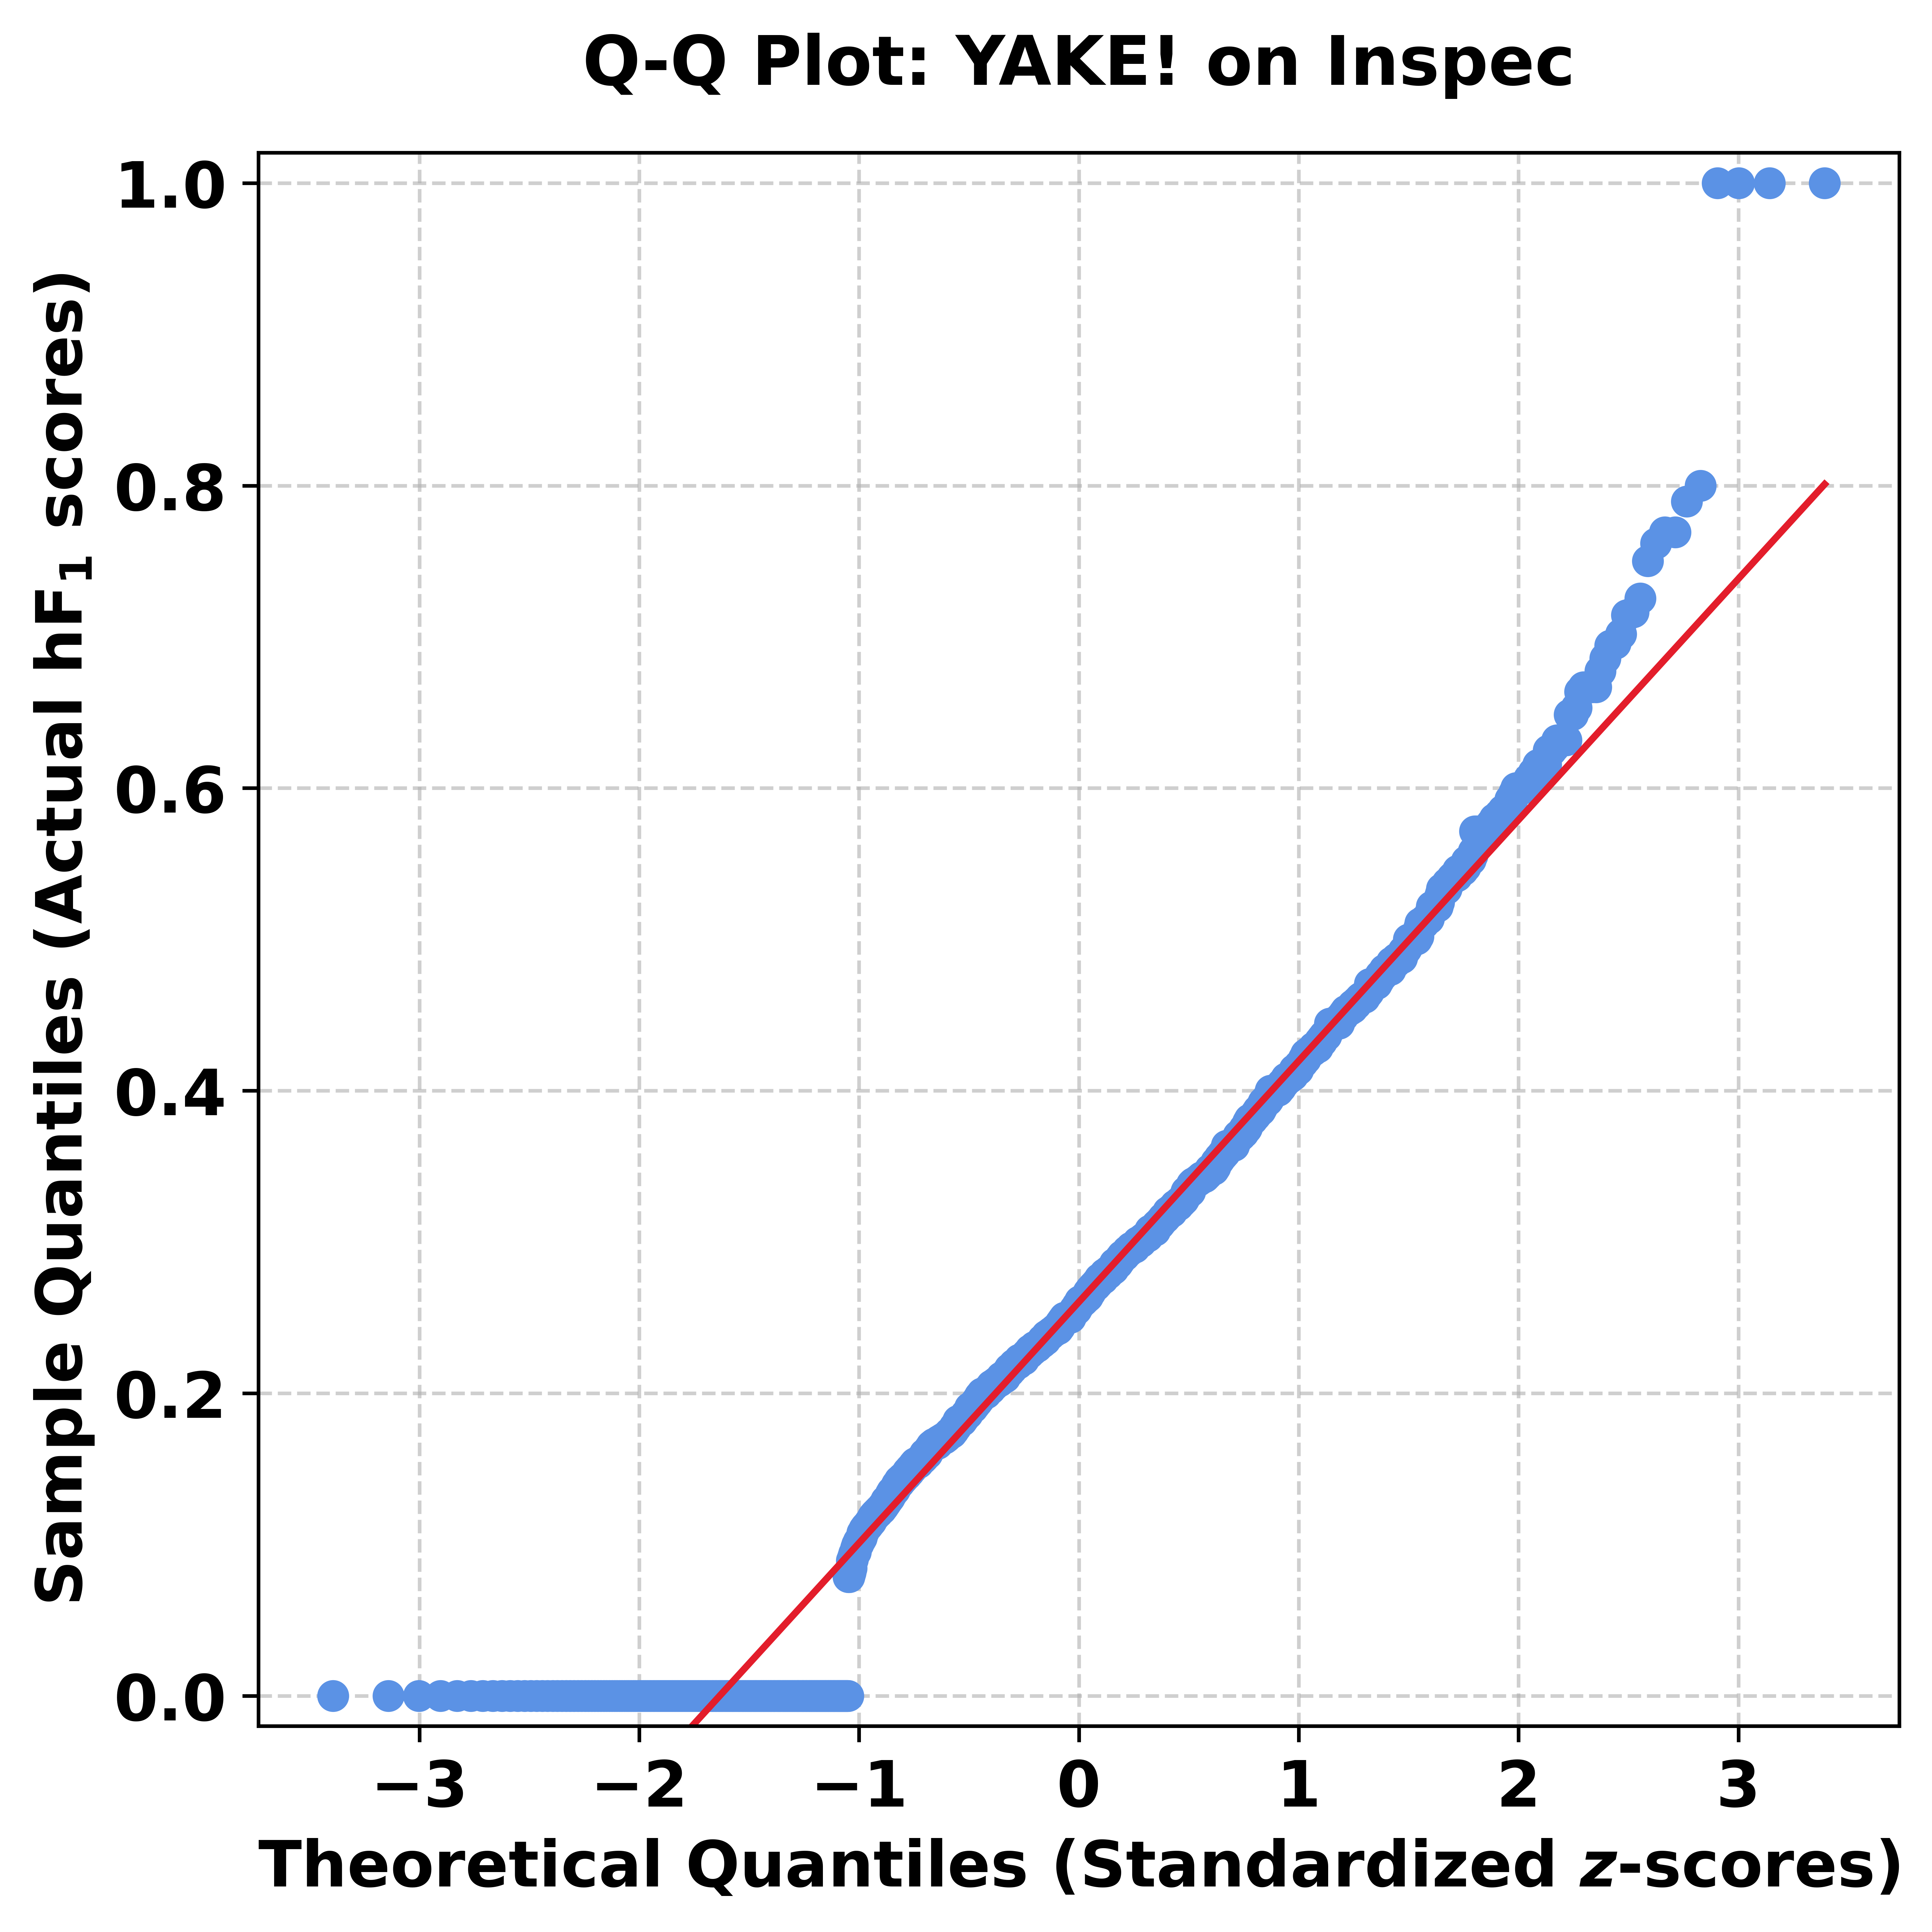

In [ ]:
target_ds = 'Inspec'
target_method = 'YAKE'

target_observations = AKE_full_hF1[AKE_full_hF1['Dataset'] == target_ds][target_method]

plt.figure(figsize=(6, 6), dpi=1000)

plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.tick_params(axis='both', which='major', labelsize=14)

stats.probplot(target_observations, dist="norm", plot=plt)

ax = plt.gca()
plt.ylim(-0.02, 1.02)
plt.grid(True, linestyle='--', alpha=0.6, zorder=0)

plt.gca().get_lines()[0].set_color('#5B92E5')
plt.gca().get_lines()[1].set_color('#E31D2B')

plt.title(f"Q-Q Plot: {target_method}! on {target_ds}", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Theoretical Quantiles)", fontsize=14)
plt.ylabel("Ordered Values (Actual hF$_{1}$ scores)", fontsize=14)

plt.tight_layout()
plt.show()

# 95% Bootstrap Confidence Inteval

In [ ]:
def get_bootstrap_ci(observations, n_bootstrap=10000, ci=95, seed=2026):
    scores = observations.values
    n = len(scores)

    original_mean = np.mean(scores)

    rng = np.random.default_rng(seed)
    resamples = rng.choice(scores, size=(n_bootstrap, n), replace=True)
    resampled_means = resamples.mean(axis=1)

    bootstrap_mean = np.mean(resampled_means)

    bootstrap_bias = bootstrap_mean - original_mean

    lower = np.percentile(resampled_means, (100 - ci) / 2)
    upper = np.percentile(resampled_means, 100 - (100 - ci) / 2)

    return original_mean, bootstrap_mean, lower, upper, bootstrap_bias

In [ ]:
ci_results = []

dataset_order = ['SemEval-2010', 'NUS', 'Inspec', 'KDD', 'WWW', 'SemEval-2017', 'DUC-2001', '500N-KP-Crowd']
AKE_methods = [col for col in AKE_full_hF1.columns if col != 'Dataset']

for ds_name in dataset_order:
    group = AKE_full_hF1[AKE_full_hF1['Dataset'] == ds_name]
    active_methods = [m for m in AKE_methods if not group[m].isnull().all()]

    for method in active_methods:
        original_mean, bootstrap_mean, lower, upper, bootstrap_bias = get_bootstrap_ci(group[method])
        ci_results.append({
            'Dataset': ds_name,
            'Method': method,
            'Original Mean': original_mean,
            'Bootstrap Mean': bootstrap_mean,
            'CI Lower': lower,
            'CI Upper': upper,
            'Bootstrap Bias': bootstrap_bias
        })

ci_df = pd.DataFrame(ci_results)

In [ ]:
ci_df

,Dataset,Method,Original Mean,Bootstrap Mean,CI Lower,CI Upper,Bootstrap Bias
0,SemEval-2010,TF,0.134386,0.134466,0.121147,0.148457,0.000080
1,SemEval-2010,TfIdf,0.206680,0.206730,0.192261,0.221594,0.000050
2,SemEval-2010,KPMiner,0.286862,0.286800,0.271797,0.301790,-0.000062
3,SemEval-2010,YAKE,0.189627,0.189767,0.175216,0.205037,0.000140
4,SemEval-2010,TextRank1,0.034677,0.034730,0.027345,0.042560,0.000053
...,...,...,...,...,...,...,...
63,500N-KP-Crowd,YAKE,0.308828,0.308839,0.299565,0.318155,0.000011
64,500N-KP-Crowd,TextRank1,0.193921,0.193889,0.186573,0.201039,-0.000032
65,500N-KP-Crowd,SingleRank,0.296857,0.296796,0.283424,0.310027,-0.000061
66,500N-KP-Crowd,PositionRank,0.315379,0.315336,0.303274,0.327190,-0.000043


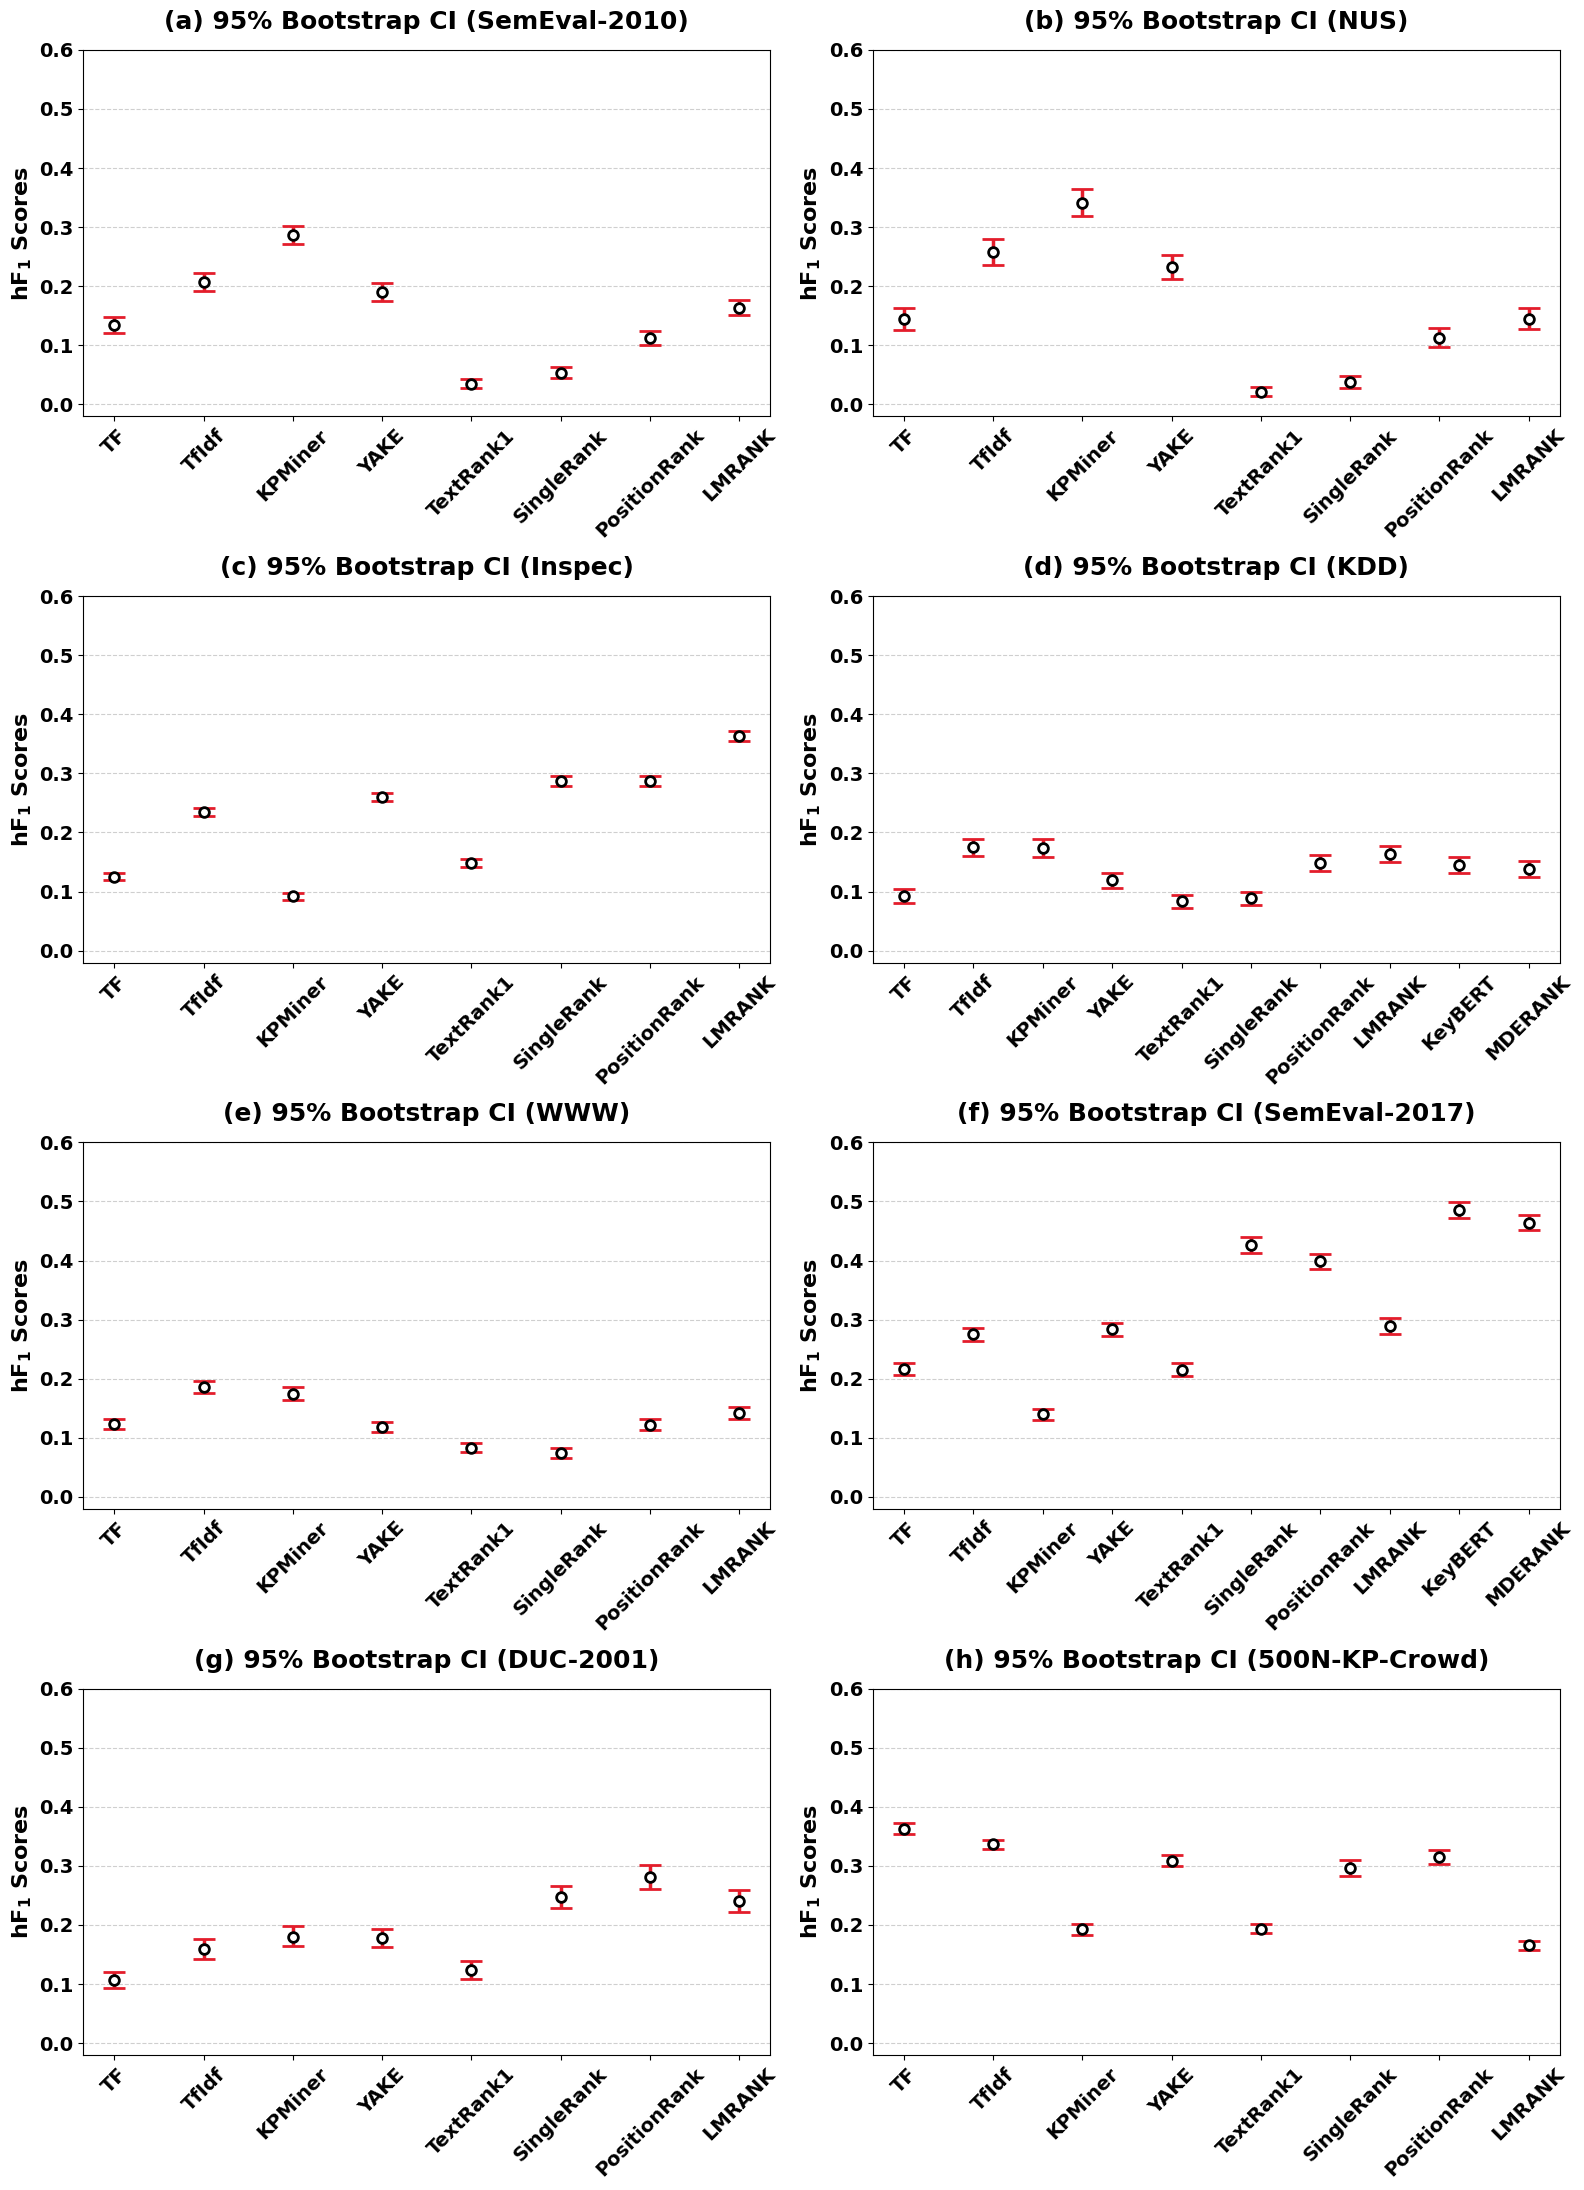

In [ ]:
import string

alphabet = list(string.ascii_lowercase)

fig, axes = plt.subplots(4, 2, figsize=(16, 22))
axes_flat = axes.flatten()

for i, ds_name in enumerate(dataset_order):
    ax = axes_flat[i]
    ax.tick_params(axis='x', rotation=45, labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.set_ylim(-0.02, 0.6)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

    instance = ci_df[ci_df['Dataset'] == ds_name]

    yerr = [instance['Original Mean'] - instance['CI Lower'], instance['CI Upper'] - instance['Original Mean']]

    ax.errorbar(x=instance['Method'], y=instance['Original Mean'], yerr=yerr,
                fmt='o', color='black', ecolor='#E31D2B', capsize=8,
                elinewidth=2.5, mfc='white', ms=7, mew=2)

    ax.set_title(f"({alphabet[i]}) 95% Bootstrap CI ({ds_name})", fontsize=18, fontweight='bold', pad=15)
    ax.set_ylabel("hF$_{1}$ Scores", fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

# Friedman Test & Nemeiny Posthoc Test

In [ ]:
!pip install scikit-posthocs

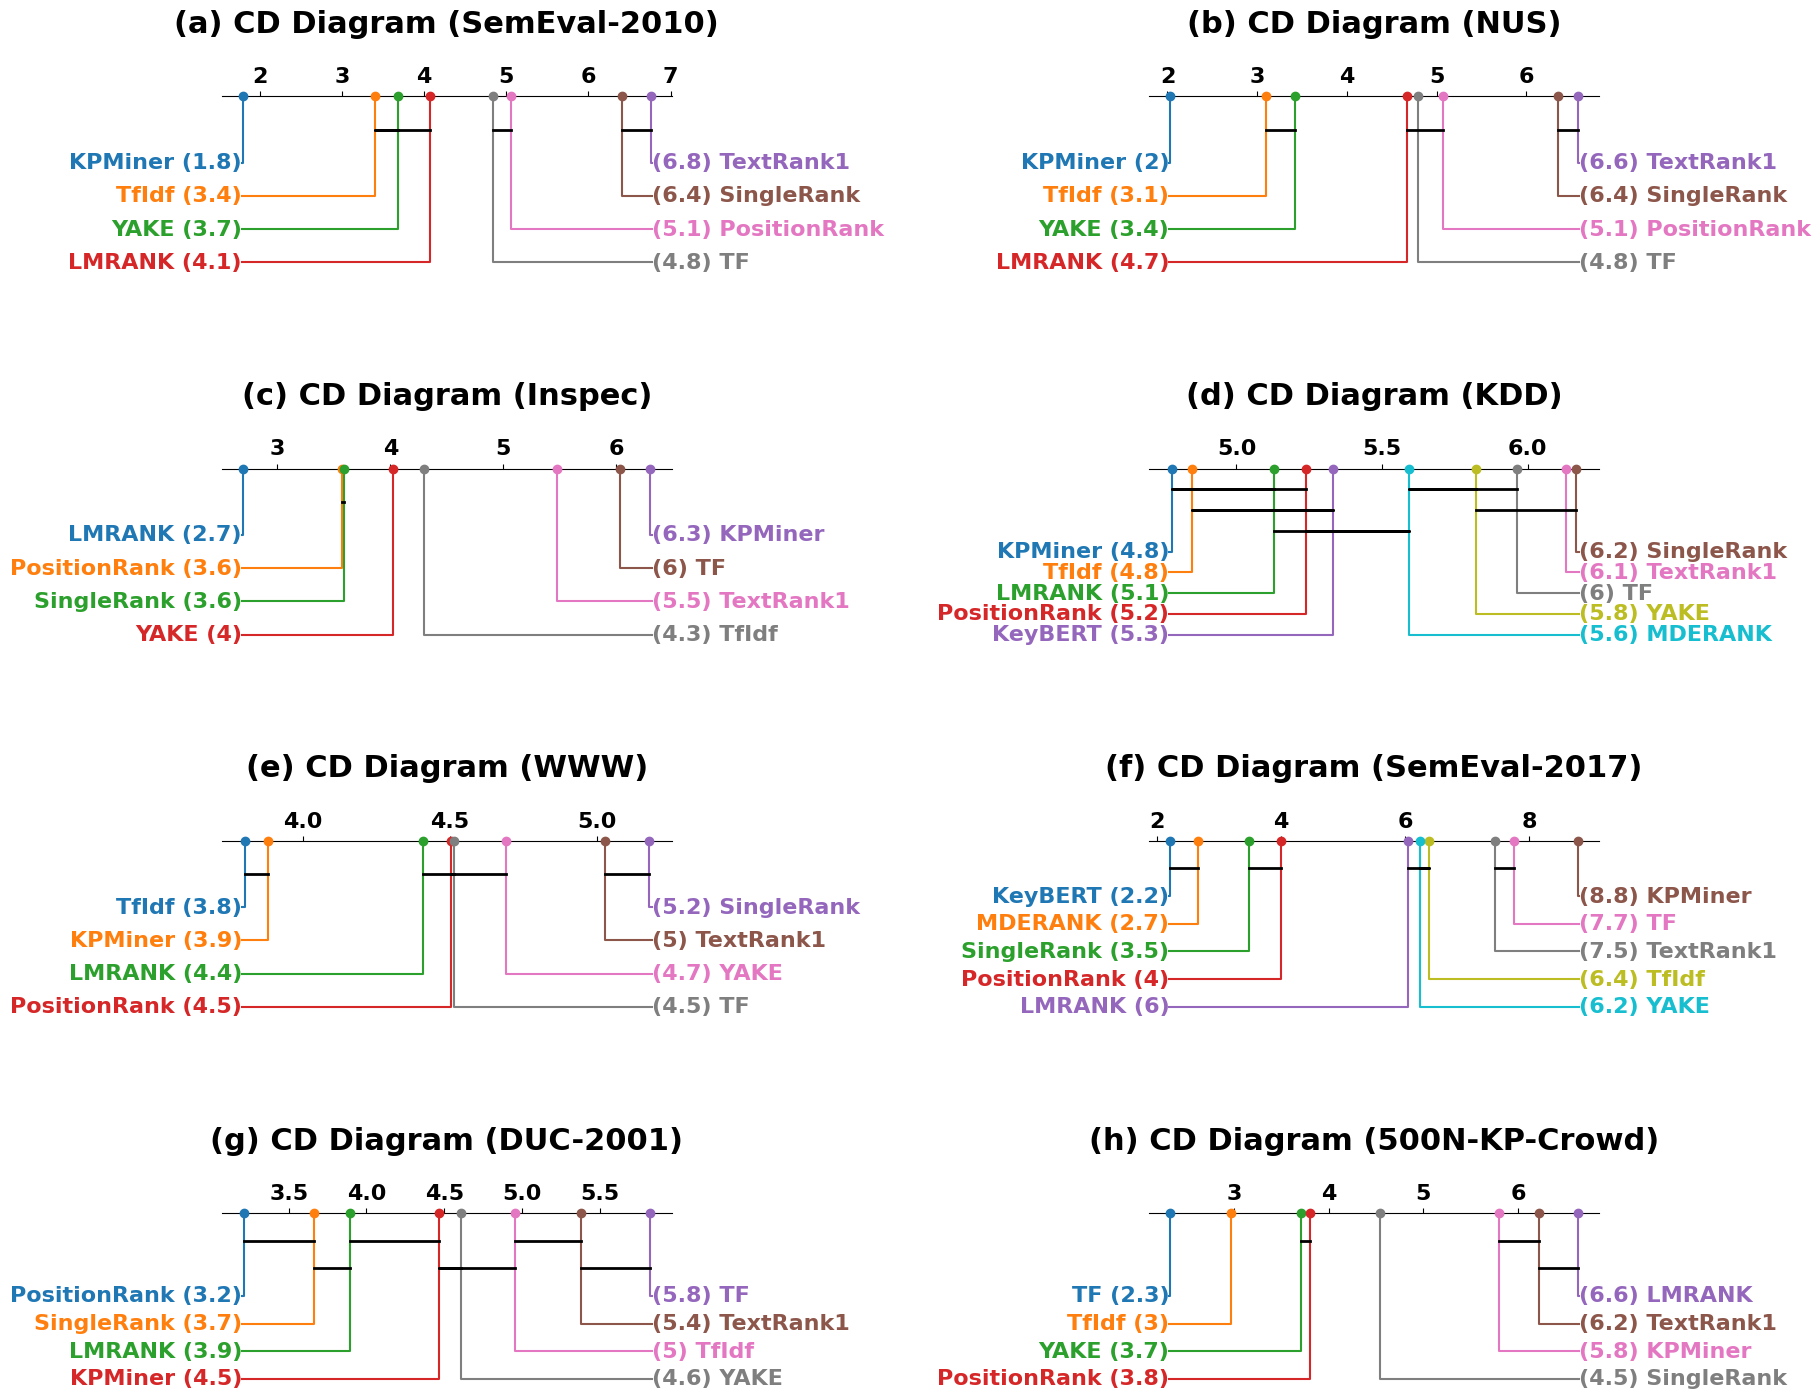

In [ ]:
import scikit_posthocs as sp

friedman_results = []
posthoc_matrices = {}

fig, axes = plt.subplots(4, 2, figsize=(20, 16))
axes_flat = axes.flatten()

plt.rcParams.update({
    'axes.titleweight': 'bold',
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'font.size': 16,
    'xtick.labelsize': 16
})

for i, ds_name in enumerate(dataset_order):
    ax = axes_flat[i]

    group = AKE_full_hF1[AKE_full_hF1['Dataset'] == ds_name]

    active_methods = [m for m in AKE_methods if not group[m].isnull().all()]
    group_df = group[active_methods]

    stat, p_val = stats.friedmanchisquare(*[group_df[m] for m in active_methods])

    friedman_results.append({
        'Dataset': ds_name,
        'Friedman Stat': stat,
        'p-value': p_val,
        'Significant': 'Yes' if p_val < 0.05 else 'No'
    })

    if p_val < 0.05:
        posthoc_df = sp.posthoc_nemenyi_friedman(group_df)
        posthoc_matrices[ds_name] = posthoc_df

        group_rank_df = group_df.rank(axis=1, ascending=False)
        group_avg_ranks = group_rank_df.mean()

        plt.sca(ax)
        sp.critical_difference_diagram(group_avg_ranks, posthoc_df)

        ax.set_title(f"({alphabet[i]}) CD Diagram ({ds_name})",
                     pad=40, fontsize=22, fontweight='bold')
    else:
        ax.text(0.5, 0.5, f"No significant difference found.",
                ha='center', va='center', fontsize=16)
        ax.axis('off')

plt.tight_layout(pad=5.0)

plt.show()

plt.rcdefaults()

friedman_df = pd.DataFrame(friedman_results)

In [ ]:
friedman_df

,Dataset,Friedman Stat,p-value,Significant
0,SemEval-2010,807.766430,3.912926e-170,Yes
1,NUS,725.068048,2.711855e-152,Yes
2,Inspec,4291.059828,0.000000e+00,Yes
3,KDD,328.646687,2.157118e-65,Yes
4,WWW,595.123045,2.733318e-124,Yes
5,SemEval-2017,2580.890547,0.000000e+00,Yes
6,DUC-2001,310.301415,3.812598e-63,Yes
7,500N-KP-Crowd,1458.245080,9.616542e-311,Yes


In [ ]:
posthoc_matrices['SemEval-2010']

,TF,TfIdf,KPMiner,YAKE,TextRank1,SingleRank,PositionRank,LMRANK
TF,1.000000e+00,3.541033e-09,1.110223e-16,5.726472e-06,1.110223e-16,3.349843e-11,9.735318e-01,1.365968e-02
TfIdf,3.541033e-09,1.000000e+00,9.254375e-12,9.205960e-01,1.110223e-16,1.110223e-16,2.853051e-12,5.568113e-02
KPMiner,1.110223e-16,9.254375e-12,1.000000e+00,5.551115e-16,1.110223e-16,1.110223e-16,1.110223e-16,1.110223e-16
YAKE,5.726472e-06,9.205960e-01,5.551115e-16,1.000000e+00,1.110223e-16,1.110223e-16,1.576395e-08,6.502977e-01
TextRank1,1.110223e-16,1.110223e-16,1.110223e-16,1.110223e-16,1.000000e+00,7.624828e-01,4.501954e-13,1.110223e-16
SingleRank,3.349843e-11,1.110223e-16,1.110223e-16,1.110223e-16,7.624828e-01,1.000000e+00,2.990866e-08,1.110223e-16
PositionRank,9.735318e-01,2.853051e-12,1.110223e-16,1.576395e-08,4.501954e-13,2.990866e-08,1.000000e+00,2.363464e-04
LMRANK,1.365968e-02,5.568113e-02,1.110223e-16,6.502977e-01,1.110223e-16,1.110223e-16,2.363464e-04,1.000000e+00


# Extract Requirements

In [ ]:
!pip freeze > AKE_Statistical_Analyisis.txt